# Customer Sales Analysis

#### Statistical Analysis of Business Questions


In [2]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

In [3]:
# Import datasets
customers = pd.read_csv('data/data/customers.csv')
transactions = pd.read_csv('data/data/transactions.csv')
web_sessions=pd.read_csv('data/data/web_sessions.csv')
campaign_touchpoints=pd.read_csv('data/data/campaign_touchpoints.csv')                        

Exploring Data

In [99]:
customers.columns

Index(['customer_id', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date', 'customer_status', 'loyalty_tier', 'campaign_id',
       'last_active_date'],
      dtype='str')

In [257]:
customers.head

<bound method NDFrame.head of       customer_id   age  gender      country acquisition_channel signup_date  \
0               1  56.0   Other      Germany            referral  2019-07-21   
1               2  38.0   Other  Netherlands               email  2022-03-04   
2               3  28.0   Other    Australia            referral  2024-05-21   
3               4  19.0  Female    Australia         paid_search  2022-06-28   
4               5  38.0  Female    Australia            referral  2024-07-17   
...           ...   ...     ...          ...                 ...         ...   
9995         9996   NaN    Male           US             organic  2022-01-19   
9996         9997  21.0  Female        Spain             organic  2023-12-11   
9997         9998  50.0  Female           US         paid_search  2021-12-05   
9998         9999  30.0    Male  Netherlands            referral  2023-08-22   
9999        10000  40.0  Female       Canada              social  2019-03-27   

     cust

In [100]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date', 'is_refunded', 'refund_date',
       'refund_reason'],
      dtype='str')

In [101]:
web_sessions.columns

Index(['session_id', 'customer_id', 'pages_viewed', 'time_on_site',
       'device_type', 'traffic_source', 'session_date', 'converted', 'bounce',
       'cart_additions', 'checkout_started', 'exit_page', 'browser',
       'is_logged_in'],
      dtype='str')

In [102]:
campaign_touchpoints.columns

Index(['customer_id', 'campaign_id', 'touchpoint_id', 'touchpoint_date',
       'clicked', 'converted'],
      dtype='str')

### Specific questions

Q1. Do customers from the UK spend more per transaction than customers from Germany?

In [ ]:
#Analysis 

Uk_merged= customers[['customer_id', 'country']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

uk_spend= Uk_merged[Uk_merged['country']== 'UK']

In [104]:
Germany_merged= customers[['customer_id', 'country']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

Germany_spend= Germany_merged[Germany_merged['country']== 'Germany']

In [105]:
#Average Spend
print(uk_spend['purchase_value'].mean())
print(Germany_spend['purchase_value'].mean())

234.83599716362346
239.02857116244414


In [106]:
#T-test
t_stats, p_value = ttest_ind(
    uk_spend['purchase_value'],
    Germany_spend['purchase_value']
)

In [107]:
print(t_stats)
print(p_value)

-0.861552532139048
0.38895256953802626


**Business Interpretation** UK customers had a higher average purchase value than Germany customers, but the difference was not statistically significant based on the P_value (p = 0.389)

Q2. Do discounted purchases differ in average value from non-discounted purchases?

In [9]:
transaction= transactions[['purchase_value', 'discount_used']]

In [10]:
Discounted= transaction[transaction['discount_used']== 1]

In [11]:
non_discounted=transaction[transaction['discount_used']== 0]

In [12]:
np.mean(Discounted)



np.float64(118.30370915274287)

In [13]:
np.mean(non_discounted)

np.float64(117.28230158225837)

In [14]:
t_stats, p_value=ttest_ind(
    Discounted['purchase_value'],
    non_discounted['purchase_value']

   
)

print(t_stats)
print(p_value)


0.4009300524446949
0.6884735268380615


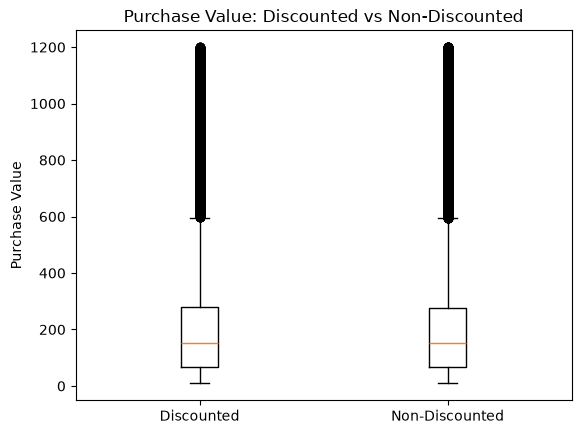

In [20]:
plt.boxplot(
    [
        Discounted['purchase_value'],
        non_discounted['purchase_value']
    ],
    tick_labels=['Discounted', 'Non-Discounted']
)

plt.ylabel('Purchase Value')
plt.title('Purchase Value: Discounted vs Non-Discounted')
plt.show()

### Business Interpretation
There is no statistically significant difference in purchase value between transactions where a discount was used and those where no discount was used (p = 0.689). The graph also shows that the purchase value distributions for the two groups are very similar, suggesting that discounts did not have a meaningful impact on purchase value in this dataset.


Q3. Do male and female customers differ in average purchase value?

In [114]:
Male_merged= customers[['customer_id', 'gender']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

Male_spend= Male_merged[Male_merged['gender']== 'Male']

In [115]:
Female_merged= customers[['customer_id', 'gender']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

Female_spend= Female_merged[Female_merged['gender']== 'Female']

In [116]:
print(Female_spend['purchase_value'].mean())
print(Male_spend['purchase_value'].mean())

235.93833125451326
234.8114863258026


In [117]:
t_stats, p_value=ttest_ind(
    Male_spend['purchase_value'],
    Female_spend['purchase_value']
)

print(t_stats)
print(p_value)

-0.387526008658225
0.6983695499097058


**Business Interpretation** Female customers had a slightly higher average purchase value than male customers, but the difference was not statistically significant (t = -0.388, p = 0.698)

Q4. Do customers acquired via email spend more than those from social channels?


In [118]:
Email_merged= customers[['customer_id', 'acquisition_channel']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

Email_spend= Email_merged[Email_merged['acquisition_channel']== 'Email']

In [119]:
Social_Media_merged= customers[['customer_id', 'acquisition_channel']].merge(
    transactions[['customer_id', 'purchase_value']],
    on='customer_id', how='inner'
    )

Social_Media_spend= Social_Media_merged[Social_Media_merged['acquisition_channel']== 'social']

In [120]:
print(Social_Media_spend['purchase_value'].count())
print(Email_spend['purchase_value'].count())


8602
1292


In [121]:
t_stats, p_value=ttest_ind(
    Email_spend['purchase_value'],
    Social_Media_spend['purchase_value']
)

print(t_stats)
print(p_value)

1.3548377168136536
0.17550020707549838


**Business Interpretation** Average purchase value of from customers from Email is higher than the average purchase value of customers from social media but the difference was not statistically significant (t = 1.355, p = 0.175)

Q5. Is device type associated with conversion?

In [122]:
table=pd.crosstab(
    web_sessions['device_type'],
    web_sessions['converted']
)

print(table)

converted        0     1
device_type             
desktop      20020  3068
mobile       20213  3042
tablet       20244  3013


In [123]:
chi2, p_value, dof, expected=chi2_contingency(table)

In [124]:
print(f"chi2 statistic: {chi2:.3f}")
print(f"p_value: {p_value:.5f}")

chi2 statistic: 1.150
p_value: 0.56265


**Business Interpretation** There is no statistically significant association between device type and conversion (χ² = 1.150, p = 0.563)

Q6. Is acquisition channel associated with conversion?

In [125]:
table=pd.crosstab(
    customers['acquisition_channel'],
    web_sessions['converted']
)

print(table)

converted               0    1
acquisition_channel           
Email                 251   31
email                1658  280
organic              1577  247
paid_Search           171   25
paid_search          1716  237
referral             1670  226
social               1640  271


In [126]:
chi2, p_value, dof, expected=chi2_contingency(table)

In [127]:
print(f"chi2 statistic: {chi2:.3f}")
print(f"p_value: {p_value:.5f}")

chi2 statistic: 10.315
p_value: 0.11202


**Business Interpretation** There is no statistically significant association between acquisition channel and conversion (χ² = 10.315, p = 0.112)

Q7. Is product category associated with discount usage?

In [130]:
table=pd.crosstab(
    transactions['product_category'],
    transactions['discount_used']
)

print(table)

discount_used        0     1
product_category            
beauty            5305  2281
electronics       5212  2212
fashion           5326  2255
home              5210  2278
sports            5225  2279
toys              5196  2221


In [131]:
chi2, p_value, dof, expected=chi2_contingency(table)

In [132]:
print(f"chi2 statistic: {chi2:.3f}")
print(f"p_value: {p_value:.5f}")

chi2 statistic: 1.462
p_value: 0.91739


**Business Interpretation** There is no statistically significant association between product category and discount_used (chi2 = 1.462, p = 0.917)

Q8. Is time on site correlated with purchase value?

In [146]:
corr_merge= web_sessions[['customer_id' , 'time_on_site']].merge(
                          transactions[['customer_id' , 'purchase_value']], on='customer_id' , how= 'inner')
                                        

In [147]:
r, p_value, = pearsonr(
    corr_merge['time_on_site'],
    corr_merge['purchase_value']
)

In [148]:
print(f"Correlation: {r:.3f}")
print(f"P-value: {p_value:.5f}")

Correlation: 0.000
P-value: 0.92673


**Business Interpretation** There is no significant linear relationship between time spent on the website and purchase value (r = 0.000, p = 0.927).

Q9. Is number of pages viewed correlated with purchase value?

In [5]:
corr_pg= web_sessions[['customer_id', 'pages_viewed']].merge(
    transactions[['customer_id', 'purchase_value']], on='customer_id'
, how='inner' )

In [6]:
r, p_value=pearsonr(
    corr_pg['pages_viewed'],
    corr_pg['purchase_value']
)

In [151]:
print(f"correlation:{r:-3f}")
print(f" p-value:{p_value:5f}")

correlation:-0.003584
 p-value:0.044178


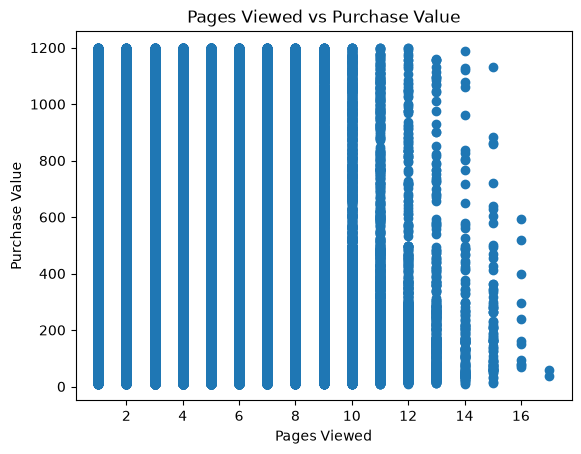

In [7]:
import matplotlib.pyplot as plt

plt.scatter(
    corr_pg['pages_viewed'],
    corr_pg['purchase_value']
)

plt.xlabel('Pages Viewed')
plt.ylabel('Purchase Value')
plt.title('Pages Viewed vs Purchase Value')
plt.show()

**Business Interpretation** There is a statistically significant relationship but negative correlation between the pages_viewed and purchase_value (r = -0.004, p = 0.044).

Q10. Is time on site correlated with pages viewed?

In [152]:
r, p_value =pearsonr(
    web_sessions['time_on_site'],
    web_sessions['pages_viewed']
)

In [153]:
print(f" correlation:{r:3f}")
print(f" p_value:{p_value:5f}")

 correlation:0.004540
 p_value:0.229322


**Business Interpretation** The is no statistically significant relationship and a linear correlation between the pages_viewed and time_on_site (r = 0.005, p = 0.229)

### Relationship Exploration

1. Does high-spending customers behave differently in terms of session time.



High-spending customers are customers whose purchase value falls within the top 25% of all purchase values (at or above the 75th percentile).

In [189]:
Mark= transactions['purchase_value'].quantile(0.75)

High_Spenders= transactions[transactions['purchase_value']>= Mark ]

In [193]:
Low_Spenders= transactions[transactions['purchase_value']<= Mark]



In [194]:
HS_G1 = High_Spenders.merge(
    web_sessions[['customer_id' , 'time_on_site']], on='customer_id' , how='inner'
)

In [195]:
LS_G2= Low_Spenders.merge(
    web_sessions[['customer_id','time_on_site']], on='customer_id' , how='inner'
)

In [202]:
t_stats , p_value = ttest_ind(
    HS_G1['time_on_site'],
    LS_G2['time_on_site']
)

print(t_stats)
print(p_value)

-0.6876221172943129
0.4916912824524279


**Business Interpretation** High-spending customers did not have a statistically significant difference in session time compared with other low spending customers by the top 25% definition of high spending, therefore there was not enough statistical evidence to say that high spending customers behave differently than low spending customers. Although high spenders has a lower average time than low spenders (t = -0.688, p = 0.492)

2. Is there an association between Highest selling Product category and Age
Analysis: I will be carrying out a independent t-test

In [219]:
#Highest selling Product

HSP =transactions[['customer_id', 'product_category', 'purchase_value']].sort_values('purchase_value' ,ascending=False)




In [ ]:
#Lowest selling product

LSP=transactions[['customer_id', 'product_category', 'purchase_value']].sort_values('purchase_value' ,ascending=True)



Highest Selling Product-Electronics, and Lowest selling product is toys. 

In [ ]:
#Electronics
p_Merge= customers[['customer_id', 'age']].dropna().merge(
    transactions[['customer_id', 'purchase_value' , 'product_category']],
    on='customer_id' , how='inner'
    )
E_Merge = p_Merge[p_Merge['product_category']== 'electronics']

In [ ]:
#Toys
p_Merge= customers[['customer_id', 'age']].dropna().merge(
    transactions[['customer_id', 'purchase_value' , 'product_category']],
    on='customer_id' , how='inner'
    )
t_Merge = p_Merge[p_Merge['product_category']== 'toys']

In [236]:
#T-test

t_stats , p_value, =ttest_ind(
    E_Merge['age'],
    t_Merge['age']
)

print(t_stats)
print(p_value)

0.0
1.0


**Business Interpretation** There is no statistically significant difference in the average age of customers who purchased Electronics compared with customers who purchased other product categories (t = 0.00, p = 1.00).

This suggests that age may not be a strong differentiating factor in product-category purchasing behaviour. Customers across similar age groups appear to purchase different product categories, indicating that factors other than age may be influencing their purchasing decisions.

Therefore, marketing strategies should not rely heavily on age-based targeting for these product categories. Instead, businesses could investigate other factors such as customer needs, product pricing, promotions, product availability, income, and purchasing history when designing campaigns and promotions

3. Does customer loyalty level influence purchase value? I will be carrying an ANOVA test

In [285]:
L_M = customers[['customer_id', 'loyalty_tier']].dropna().merge(
    transactions[['customer_id' , 'purchase_value']], 
    on='customer_id' , how='inner'
)


B_P = L_M[L_M['loyalty_tier']== 'bronze']




In [284]:
S_P= L_M[L_M['loyalty_tier']== 'silver']



In [283]:
N_P=L_M[L_M['loyalty_tier']== 'none']



In [282]:
G_P=L_M[L_M['loyalty_tier']== 'gold']



In [287]:
from scipy.stats import f_oneway

f_stats, p_value = f_oneway(
    G_P['purchase_value'],
    B_P['purchase_value'],
    S_P['purchase_value'],
    N_P['purchase_value']
)

In [288]:
print(f_stats)
print(p_value)

1.1902419815485488
0.31171728511299635


**Business Interpretation** There is no statistically significant difference in average purchase value across customers with no loyalty membership, Bronze, Silver, and Gold loyalty tiers (F = 1.190, p = 0.312)

It suggests that loyalty tier is not significantly associated with purchase value in this dataset. In other words, Gold, Silver, and Bronze members do not appear to have significantly higher transaction values than customers without a loyalty tier. This suggests that the company should look beyond transaction value when evaluating the effectiveness of its loyalty programme and focus on metrics such as purchase frequency, customer retention, and customer lifetime value.

3b. Does Loyalty tier influence → purchase frequency

In [291]:
purchase_count = transactions.groupby('customer_id').size().reset_index(name='purchase_count')



In [294]:
L_purchase = customers[['customer_id', 'loyalty_tier']].merge(
    purchase_count,
    on='customer_id',
    how='inner'
)



In [295]:
L_purchase.groupby('loyalty_tier')['purchase_count'].mean()

loyalty_tier
bronze    4.542276
gold      4.500000
none      4.572963
silver    4.555710
Name: purchase_count, dtype: float64

In [297]:
f_stat, p_value = f_oneway(
    L_purchase[L_purchase['loyalty_tier'] == 'none']['purchase_count'],
    L_purchase[L_purchase['loyalty_tier'] == 'bronze']['purchase_count'],
    L_purchase[L_purchase['loyalty_tier'] == 'silver']['purchase_count'],
    L_purchase[L_purchase['loyalty_tier'] == 'gold']['purchase_count']
)

In [298]:
print(f_stat)
print(p_value)

0.27013029533211047
0.8469782270958341


**Business Interpretation** There is no statistically significant difference in purchase frequency across customers with no loyalty membership, Bronze, Silver, and Gold tiers (F = 0.270, p = 0.847), which shows that the current loyalty programme is not significantly associated with either higher transaction value or purchase frequency, so the company should evaluate other factors that may improve customer retention and engagement.

### Statistical Significance vs. Business Importance

**Business Interpretation** I analysed the relationship between pages viewed and purchase value using a Pearson correlation test on Business Q9. The result showed a correlation of -0.004 with a p-value of 0.044. Since the p-value is below 0.05, the relationship is statistically significant. However, the correlation is almost zero, meaning the relationship is extremely weak and is unlikely to have any real business impact. This shows that a result can be statistically significant without being practically important.

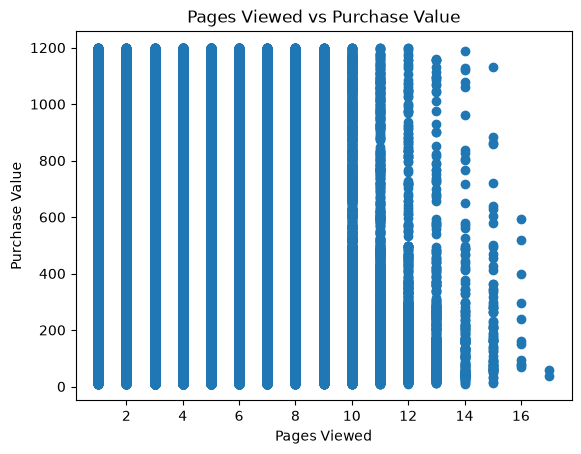